# Multiple Linear Regression

## Model : Predicting sales based on advertising on TV, Radio, Newspaper

In [64]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
data = pd.read_csv("advertising.csv")
#Display the first few rows of datasets
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [66]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [68]:
data.shape

(200, 4)

## Define the independent variables (X) and the dependent vriable (y)

In [69]:
X = data[['TV', 'Radio', 'Newspaper']] #independnt variable
y = data['Sales'] 

In [70]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [71]:
y.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales')

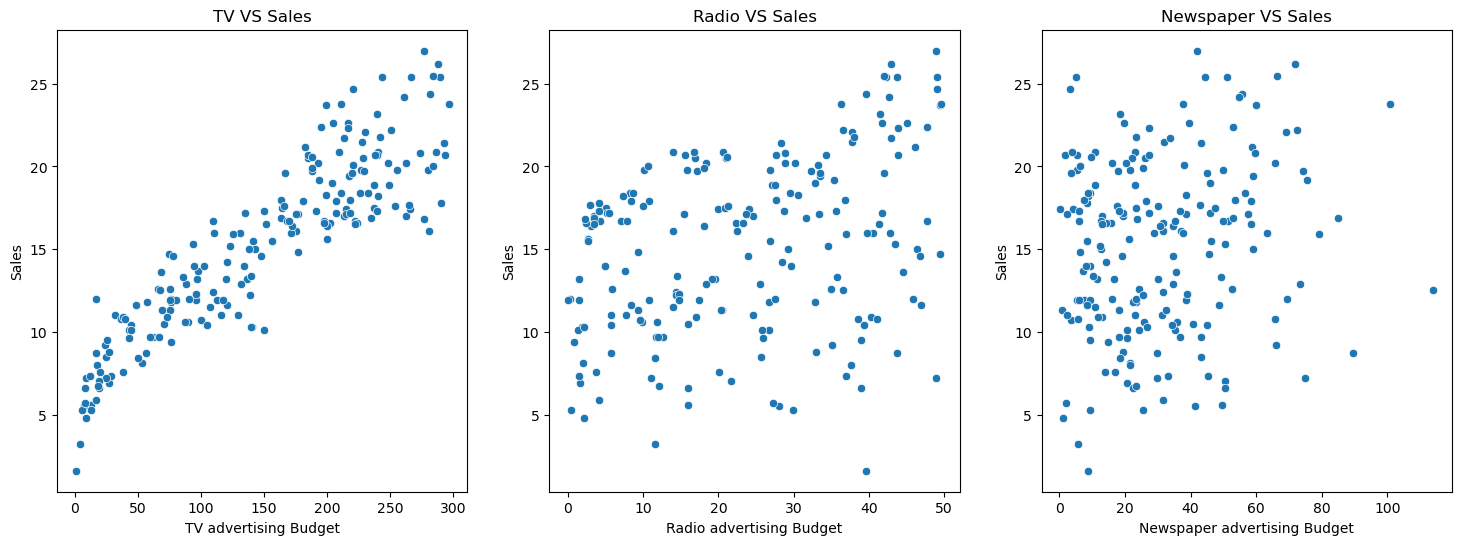

In [72]:
## plotting scatter plots

plt.figure(figsize=(18,6))

#Scatter plot for TV vs Sales
plt.subplot(1,3,1)
sns.scatterplot(x = data['TV'], y = data['Sales'])
plt.title("TV VS Sales")
plt.xlabel("TV advertising Budget")
plt.ylabel("Sales")

#Scatter plot for Radio vs Sales
plt.subplot(1,3,2)
sns.scatterplot(x = data['Radio'], y = data['Sales'])
plt.title("Radio VS Sales")
plt.xlabel("Radio advertising Budget")
plt.ylabel("Sales")

#Scatter plot for Newspaper vs Sales
plt.subplot(1,3,3)
sns.scatterplot(x = data['Newspaper'], y = data['Sales'])
plt.title("Newspaper VS Sales")
plt.xlabel("Newspaper advertising Budget")
plt.ylabel("Sales")

            


In [73]:
X.corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


## Compute the  Correlation Matrix

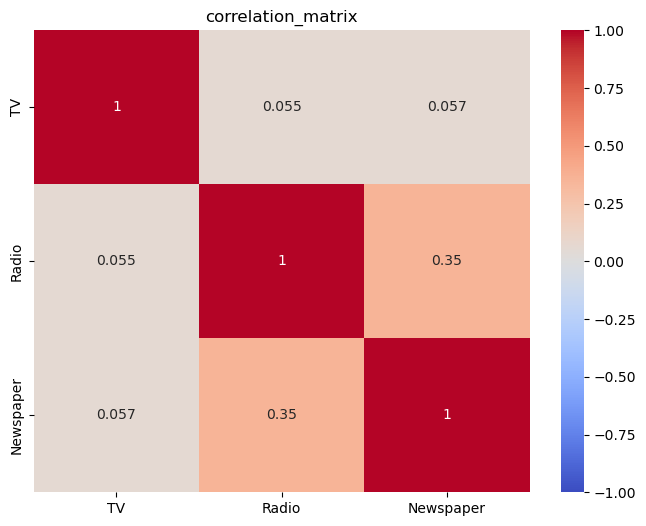

                 TV     Radio  Newspaper
TV         1.000000  0.054809   0.056648
Radio      0.054809  1.000000   0.354104
Newspaper  0.056648  0.354104   1.000000


In [74]:
correlation_matrix = X.corr()

#Plot correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm", vmin =-1, vmax=1)
plt.title("correlation_matrix")
plt.show()

#Display the correlation matrix
print(correlation_matrix)

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate the VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values,i)for i in range(X.shape[1])]
print("Variance Inflation Factors(VIF):")
print(vif_data)

Variance Inflation Factors(VIF):
     feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


## Split data into training and testing sets

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

In [77]:
X_train.head()

,TV,Radio,Newspaper
169,284.3,10.6,6.4
97,184.9,21.0,22.0
31,112.9,17.4,38.6
12,23.8,35.1,65.9
35,290.7,4.1,8.5


In [78]:
X_test.head()

,TV,Radio,Newspaper
95,163.3,31.6,52.9
15,195.4,47.7,52.9
30,292.9,28.3,43.2
158,11.7,36.9,45.2
128,220.3,49.0,3.2


In [79]:
y_test.head()

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64

In [80]:
X_test.head()

,TV,Radio,Newspaper
95,163.3,31.6,52.9
15,195.4,47.7,52.9
30,292.9,28.3,43.2
158,11.7,36.9,45.2
128,220.3,49.0,3.2


In [81]:
X_train.shape


(140, 3)

In [82]:
y_train.shape

(140,)

In [83]:
X_test.shape,y_test.shape

((60, 3), (60,))

## Create and train the linear regression model

In [84]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
y_test_pred = linear_model.predict(X_test)

## Make Predictions

In [86]:
test_results = pd.DataFrame({
    "Original Sales (test)" :y_test,
    "predicted Sales(test)": y_test_pred
})

print("Testing Data Results:\n", test_results.head())

Testing Data Results:
      Original Sales (test)  predicted Sales(test)
95                    16.9              17.159919
15                    22.4              20.533695
30                    21.4              23.689144
158                    7.3               9.519146
128                   24.7              21.607368


## Model Evaluation Techniques

### Finding the R2 Score for the model

In [87]:
R2 = r2_score(y_test, y_test_pred)
print("R2 Score:", R2)

R2 Score: 0.90914843418498


In [88]:
### Finding Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE Score:", rmse)

RMSE Score: 1.5942471691143583


In [89]:
from sklearn.metrics import mean_absolute_error

In [90]:
### Finding Mean Aolute Error

mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Aolute Error Score:", mae)

Mean Aolute Error Score: 1.159487506109058


In [91]:
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
mape

np.float64(10.536440823029304)

## Residual Plot

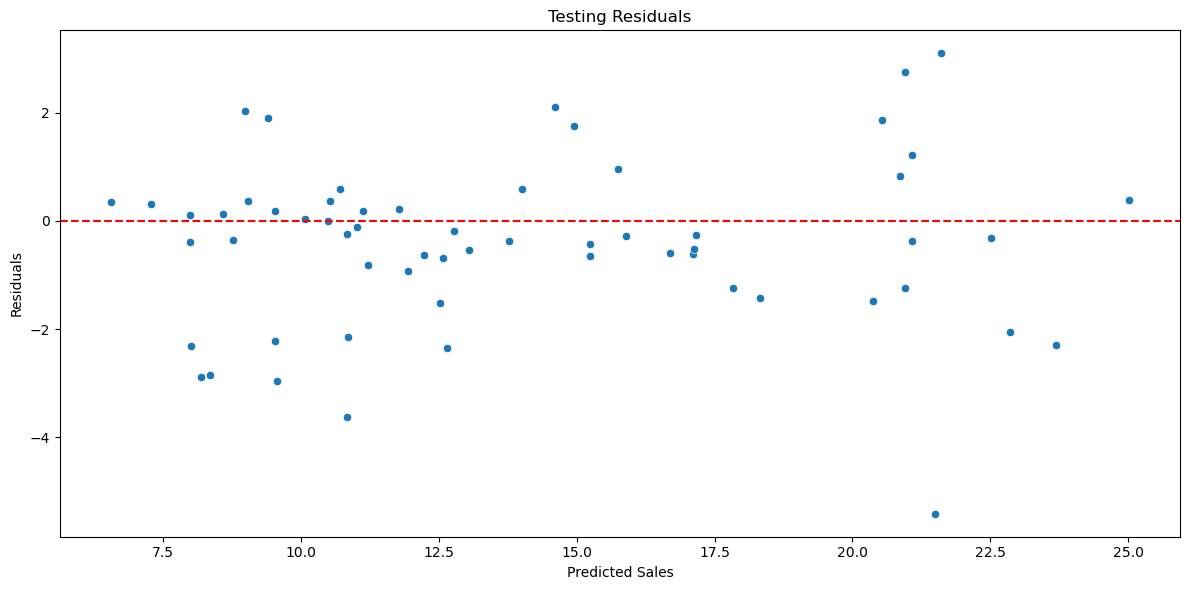

In [92]:
residual_test = y_test - y_test_pred

# Plot Residuals
plt.figure(figsize = (12,6))
plt.subplot(1,1,1,)

sns.scatterplot(x = y_test_pred, y = residual_test)
plt.axhline(0, color = 'r', linestyle = "--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Testing Residuals")

plt.tight_layout()
plt.show()

## Display statistics of model

In [93]:
import statsmodels.api as sm

# Add a constant to the model(intercept)

X_train_const = sm.add_constant(X_train)

#Fit the OlS model with intercept
ols_model = sm.OLS(y_train, X_train_const).fit()

# Print the summary to get p -values

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     374.3
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.69e-65
Time:                        21:11:22   Log-Likelihood:                -271.70
No. Observations:                 140   AIC:                             551.4
Df Residuals:                     136   BIC:                             563.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7438      0.400     11.863      0.0

In [94]:
X1 = data[['TV','Radio']]
y1 = data['Sales']

In [95]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size =0.3, random_state =42)

In [96]:
X1_train.head()

,TV,Radio
169,284.3,10.6
97,184.9,21.0
31,112.9,17.4
12,23.8,35.1
35,290.7,4.1


In [97]:
y1_train.head()

169    20.0
97     20.5
31     11.9
12      9.2
35     17.8
Name: Sales, dtype: float64

In [98]:
X1_train.shape, y1_train.shape

((140, 2), (140,))

In [99]:
X1_test.head()

,TV,Radio
95,163.3,31.6
15,195.4,47.7
30,292.9,28.3
158,11.7,36.9
128,220.3,49.0


In [100]:
y1_test.head()

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64

In [101]:
model1 = LinearRegression()

In [102]:
model1.fit(X1_train, y1_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
y1_pred_test = model1.predict(X1_test)

In [106]:
r2_test1 = r2_score(y1_test,y1_pred_test)
r2_test1

0.9139189919346896

In [108]:
import statsmodels.api as sm

# Add a constant to the model(intercept)

X_train_const1 = sm.add_constant(X1_train)

#Fit the OlS model with intercept
ols_model1 = sm.OLS(y_train, X_train_const1).fit()

# Print the summary to get p -values

print(ols_model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     560.3
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.11e-66
Time:                        21:43:16   Log-Likelihood:                -272.28
No. Observations:                 140   AIC:                             550.6
Df Residuals:                     137   BIC:                             559.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8921      0.375     13.046      0.0

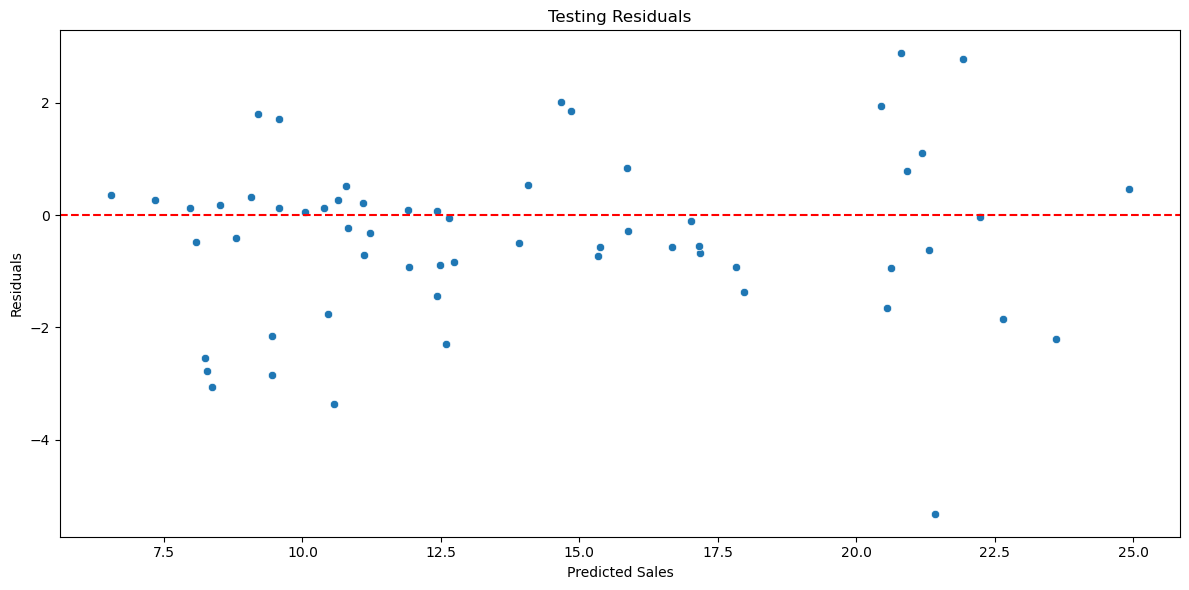

In [111]:
residual_test1 = y1_test - y1_pred_test

# Plot Residuals
plt.figure(figsize = (12,6))
plt.subplot(1,1,1,)

sns.scatterplot(x = y1_pred_test, y = residual_test1)
plt.axhline(0, color = 'r', linestyle = "--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Testing Residuals")

plt.tight_layout()
plt.show()